✅ Libraries Loaded & Seeds Set
⏳ Loading dataset from 'dataset.csv'...
📊 Dataset Loaded: 100 rows
    Case_ID       Date  Patient_Age Patient_Gender       City        State  \
0  CASE-100 2026-01-01           44          Other     Mumbai  Maharashtra   
1  CASE-068 2026-01-01           30          Other     Jaipur    Rajasthan   
2  CASE-032 2026-01-01           55          Other  Bangalore    Karnataka   
3  CASE-064 2026-01-02           46              M      Delhi        Delhi   
4  CASE-051 2026-01-02           52              M      Delhi        Delhi   

   Pincode  Medicine_Name   Batch_ID  \
0   400067          Pan-D    PND-E15   
1   302001      Combiflam    CBF-G11   
2   560034       Dolo-650    DLO-B10   
3   110092  Metformin-500  MET-DZ-99   
4   110092  Metformin-500  MET-DZ-99   

                                           Narrative  \
0            Slight tiredness after taking medicine.   
1          Sab theek chal raha hai. No side effects.   
2          Tablet li hai

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:24:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:24:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 Macro F1-Score (Fold 2): 0.5208

--- FOLD 3 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:24:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 Macro F1-Score (Fold 3): 0.6698

🏆 FINAL MODEL EVALUATION REPORT

1️⃣ DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           1       1.00      0.80      0.89        10
           2       0.80      1.00      0.89         8
           3       0.40      1.00      0.57         2
           4       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         2

    accuracy                           0.80        25
   macro avg       0.64      0.76      0.67        25
weighted avg       0.77      0.80      0.77        25


2️⃣ CONFUSION MATRIX (Actual vs Predicted)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


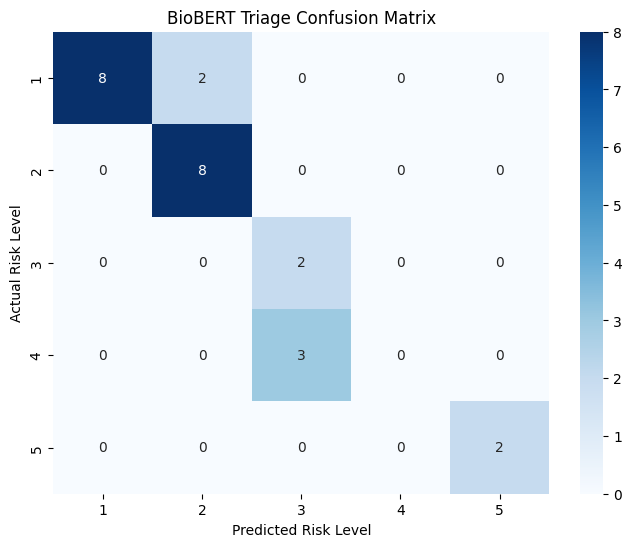


3️⃣ VALIDATION STABILITY ANALYSIS
Average Macro F1 across 3 Time-Splits: 0.6147
✅ Model is STABLE across time periods.

🤖 TEST INFERENCE:
Input: 'I am having severe difficulty breathing and chest pain.'
🔄 Extracting Embeddings for 1 samples...
Predicted Risk Level: 2


In [4]:
# ==========================================
# MEDICIOVA NOTEBOOK 1: RISK TRIAGE ENGINE
# Model: BioBERT (Feature Extractor) + XGBoost (Classifier)
# Validation: Time-Series Split (Rolling Origin)
# ==========================================

# --- STEP 1: INSTALL DEPENDENCIES ---
!pip install transformers torch scikit-learn xgboost pandas seaborn matplotlib

# --- STEP 2: IMPORTS & SETUP ---
import torch
import pandas as pd
import numpy as np
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder

# Set Seeds for Reproducibility (As per Report)
torch.manual_seed(42)
np.random.seed(42)

print("✅ Libraries Loaded & Seeds Set")

# --- STEP 3: LOAD DATASET FROM CSV ---
# Assuming the dataset is provided as 'dataset.csv' in the runtime environment
print("⏳ Loading dataset from 'dataset.csv'...")
df = pd.read_csv('dataset.csv')
# Rename 'Date_Reported' to 'Date' for consistency with original code logic
# This addresses the KeyError as the loaded CSV has 'Date_Reported' not 'Date'
if 'Date_Reported' in df.columns and 'Date' not in df.columns:
    df.rename(columns={'Date_Reported': 'Date'}, inplace=True)
# Rename 'Narrative_Text' to 'Narrative' for consistency with original code logic
# This addresses the KeyError as the loaded CSV has 'Narrative_Text' not 'Narrative'
if 'Narrative_Text' in df.columns and 'Narrative' not in df.columns:
    df.rename(columns={'Narrative_Text': 'Narrative'}, inplace=True)
# Ensure 'Date' column is in datetime format and sort the DataFrame
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date').reset_index(drop=True)
print(f"📊 Dataset Loaded: {df.shape[0]} rows")
print(df.head())
print(df.info())

# --- STEP 4: LOAD BioBERT MODEL ---
print("⏳ Loading BioBERT Model (dmis-lab/biobert-v1.1)...")
tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-v1.1")
model = AutoModel.from_pretrained("dmis-lab/biobert-v1.1")

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# --- STEP 5: FEATURE EXTRACTION (The "Embedding" Layer) ---
def get_biobert_embeddings(text_list):
    """
    Converts text to 768-dimensional BioBERT vectors.
    """
    model.eval()
    embeddings = []

    # Process in batches to save RAM
    batch_size = 16
    print(f"🔄 Extracting Embeddings for {len(text_list)} samples...")

    for i in range(0, len(text_list), batch_size):
        batch = text_list[i : i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        # Take the [CLS] token embedding (First token) as the sentence representation
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.extend(cls_embeddings)

    return np.array(embeddings)

# Generate X (Features) and y (Target)
X_embeddings = get_biobert_embeddings(df['Narrative'].tolist())
y = df['Risk_Level'].values

# Encode Labels (XGBoost expects 0, 1, 2...)
le = LabelEncoder()
y_encoded = le.fit_transform(y) # e.g., Level 1 -> 0, Level 2 -> 1...

print(f"✅ Features Ready: {X_embeddings.shape}")

# --- STEP 6: VALIDATION STRATEGY (Rolling Origin Cross-Validation) ---
# As per report: "We do not use random split to avoid Look-Ahead Bias."
# We train on Past, Test on Future.

tscv = TimeSeriesSplit(n_splits=3)
fold = 1
metrics_log = []

print("\n🚀 STARTING ROLLING ORIGIN VALIDATION...")

for train_index, test_index in tscv.split(X_embeddings):
    print(f"\n--- FOLD {fold} ---")
    X_train, X_test = X_embeddings[train_index], X_embeddings[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Initialize & Train XGBoost Classifier
    clf = xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=len(le.classes_),
        eval_metric='mlogloss',
        use_label_encoder=False,
        seed=42
    )

    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Calculate Metrics for this Fold
    fold_f1 = f1_score(y_test, y_pred, average='macro')
    metrics_log.append(fold_f1)

    print(f"📈 Macro F1-Score (Fold {fold}): {fold_f1:.4f}")
    fold += 1

# --- STEP 7: FINAL EVALUATION & METRICS REPORT ---
# We assume the last fold represents the most "current" model performance
print("\n" + "="*40)
print("🏆 FINAL MODEL EVALUATION REPORT")
print("="*40)

# Decode labels for readable report
y_test_decoded = le.inverse_transform(y_test)
y_pred_decoded = le.inverse_transform(y_pred)

# 1. Classification Report
print("\n1️⃣ DETAILED CLASSIFICATION REPORT")
print(classification_report(y_test_decoded, y_pred_decoded))

# 2. Confusion Matrix
print("\n2️⃣ CONFUSION MATRIX (Actual vs Predicted)")
cm = confusion_matrix(y_test_decoded, y_pred_decoded)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Risk Level')
plt.ylabel('Actual Risk Level')
plt.title('BioBERT Triage Confusion Matrix')
plt.show()

# 3. Macro F1 Trend
print("\n3️⃣ VALIDATION STABILITY ANALYSIS")
print(f"Average Macro F1 across {tscv.get_n_splits()} Time-Splits: {np.mean(metrics_log):.4f}")
if np.std(metrics_log) < 0.1:
    print("✅ Model is STABLE across time periods.")
else:
    print("⚠️ Model performance fluctuates. More data needed.")

# --- STEP 8: INFERENCE FUNCTION ---
def predict_risk(new_text):
    """
    End-to-end inference function for the Chatbot.
    """
    # 1. Vectorize
    vec = get_biobert_embeddings([new_text])
    # 2. Predict
    pred_idx = clf.predict(vec)[0]
    # 3. Decode
    risk_level = le.inverse_transform([pred_idx])[0]
    return risk_level

print("\n🤖 TEST INFERENCE:")
sample_text = "I am having severe difficulty breathing and chest pain."
print(f"Input: '{sample_text}'")
print(f"Predicted Risk Level: {predict_risk(sample_text)}")